# Priors Guide Ambiguous Line Fits

This example illustrates how informative priors resolve ambiguity when the data alone cannot identify a low-order model. We fit a 1D polynomial chaos surrogate (a line) to a tiny set of observations that cover only a narrow portion of the domain. Two competing priors (one favoring positive slopes, the other negative) lead to very different extrapolations even though the data fit quality is similar.


In [1]:
# Import statements
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from pypolymix import StochasticModel
from pypolymix.parameter_groups import GaussianGroup
from pypolymix.priors import GaussianPrior
from pypolymix.surrogate_models import PolynomialChaosExpansion


In [2]:
# Set random seed
_ = torch.manual_seed(2025)


We collect only six noisy observations clustered near the origin. Within that window the response is almost flat, so many slope/intercept pairs explain the data equally well. Outside the observed region, however, the different lines diverge dramatically.


In [3]:
# Generate scarce, ambiguous training data
num_points = 6
x_train = torch.linspace(-0.015, 0.02, num_points).unsqueeze(-1)
true_intercept = 0.12
true_slope = 0.0
noise = 0.003 * torch.randn_like(x_train)
y_train = true_intercept + true_slope * x_train + noise

print(f"x range: {x_train.min().item():+.3f} to {x_train.max().item():+.3f}")
print(f"mean y: {y_train.mean().item():.3f}")


x range: -0.015 to +0.020
mean y: 0.121


With so little spread in $x$, visual inspection already hints that the slope is underdetermined.


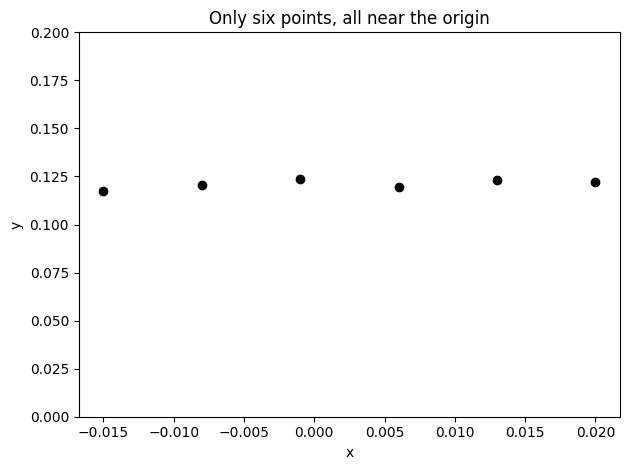

In [4]:
# Plot the scarce observations
_, ax = plt.subplots()
ax.scatter(x_train, y_train, color="black")
ax.set_xlabel("x")
ax.set_ylim(0, 0.2)
ax.set_ylabel("y")
ax.set_title("Only six points, all near the origin")
plt.tight_layout()


Next we define two priors over the line coefficients. Both favor an intercept of $0.12$, which matches the observed measurements, but one insists on a positive slope (+1) and the other on an equally strong negative slope (-1). The precision of the slope prior is considerably higher than that of the intercept, so we expect it to dominate whenever the data leave the slope unconstrained.


In [5]:
# Build and train stochastic line models under different priors
def build_model(name: str, slope_prior: float) -> StochasticModel:
    surrogate = PolynomialChaosExpansion(num_inputs=1, num_outputs=1, degree=1)
    prior_mean = torch.tensor([0.12, slope_prior])
    prior_std = torch.tensor([0.04, 0.35])
    covariance = torch.diag(prior_std ** 2)
    prior = GaussianPrior(mean=prior_mean, covariance_matrix=covariance)
    group = GaussianGroup(name, surrogate.num_params(), prior=prior)
    return StochasticModel(surrogate, group)

training_options = dict(
    num_epochs=4000,
    lr=3e-3,
    weight_decay=1e-4,
    weight_factor=5e-5,
    num_parameter_samples=128,
)

priors = {
    "positive slope prior": 1,
    "negative slope prior": -1,
}

models = {}
for label, slope_mean in priors.items():
    model = build_model(label, slope_mean)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=training_options["lr"],
        weight_decay=training_options["weight_decay"],
    )

    print(f"Training model with {label} ...")
    for epoch in range(training_options["num_epochs"]):
        optimizer.zero_grad()
        predictions = model(x_train, num_samples=training_options["num_parameter_samples"])
        target = y_train.unsqueeze(0).expand_as(predictions)

        data_loss = F.mse_loss(predictions, target)
        distribution_loss = model.distribution_loss()
        total_loss = data_loss + training_options["weight_factor"] * distribution_loss

        total_loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(
                f"Epoch {epoch + 1:4d}: data_loss={data_loss.item():.6f} | "
                f"distribution_loss={distribution_loss.item():.6f}"
            )

    models[label] = model


Training model with positive slope prior ...
Epoch 1000: data_loss=0.000682 | distribution_loss=0.898466
Epoch 2000: data_loss=0.000295 | distribution_loss=1.189126
Epoch 3000: data_loss=0.000149 | distribution_loss=1.479722
Epoch 4000: data_loss=0.000133 | distribution_loss=1.723111
Training model with negative slope prior ...
Epoch 1000: data_loss=0.000729 | distribution_loss=1.219246
Epoch 2000: data_loss=0.000248 | distribution_loss=1.528454
Epoch 3000: data_loss=0.000170 | distribution_loss=1.828431
Epoch 4000: data_loss=0.000136 | distribution_loss=2.057850


The data loss plateaus at similar values for both models, yet their priors push one solution to slope upward and the other to slope downward. We now visualize how that prior knowledge changes extrapolations away from the observed data.


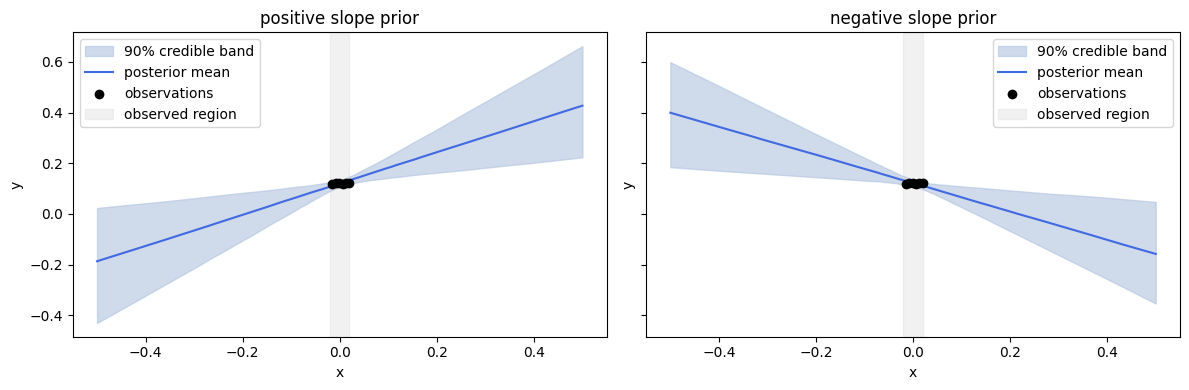

In [6]:
# Compare predictive distributions across the domain
x_test = torch.linspace(-0.5, 0.5, 400).unsqueeze(-1)
quantile_levels = torch.tensor([0.05, 0.5, 0.95])

with torch.no_grad():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, (label, model) in zip(axes, models.items()):
        samples = model(x_test, num_samples=512).squeeze(-1)
        quantiles = torch.quantile(samples, quantile_levels, dim=0)

        ax.fill_between(
            x_test.squeeze(-1).numpy(),
            quantiles[0].numpy(),
            quantiles[2].numpy(),
            color="lightsteelblue",
            alpha=0.6,
            label="90% credible band",
        )
        ax.plot(x_test, quantiles[1], color="royalblue", label="posterior mean")
        ax.scatter(x_train, y_train, color="black", zorder=3, label="observations")
        ax.axvspan(-0.02, 0.02, color="lightgray", alpha=0.3, label="observed region")
        ax.set_title(label)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend(loc="best")

    plt.tight_layout()


The priors dominate outside the tiny gray band that marks where we have data. Because the likelihood provides almost no slope information, the positive-slope prior extrapolates upward and the negative-slope prior extrapolates downward, perfectly illustrating how Bayesian priors resolve non-identifiability.


In [7]:
# Inspect posterior parameter summaries
for label, model in models.items():
    gaussian_group = model.parameter_groups[0]
    posterior = gaussian_group.variational_distribution()
    mean = posterior.mean
    std = posterior.stddev
    print(
        f"{label:>24s} -> intercept={mean[0]:+.3f} ± {std[0]:.3f}, "
        f"slope={mean[1]:+.3f} ± {std[1]:.3f}"
    )


    positive slope prior -> intercept=+0.121 ± 0.008, slope=+0.640 ± 0.274
    negative slope prior -> intercept=+0.122 ± 0.008, slope=-0.542 ± 0.275


Both solutions honor the six data points but lock onto different slope priors. Whenever measurements are scarce or localized, deliberately chosen priors allow us to encode domain knowledge and pick the physically plausible branch of the solution.
